# 1. Import Library & Setup

In [1]:
import os
import sys
import time
import warnings
import logging
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import List, Optional

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

import lightgbm as lgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

warnings.filterwarnings("ignore")

# 2. Konfigurasi Eksperimen

In [2]:
# KONFIGURASI

@dataclass
class BenchmarkConfig:
    """Parameter sentral untuk seluruh eksperimen."""

    # ── Paths ──
    tabular_path: str = "dataset_hrv_tabular.csv"
    sequence_path: str = "dataset_hrv_sequence_23p.npz"

    # ── Cross-Validation ──
    n_splits: int = 5
    random_state: int = 42

    # ── Fitur Tabular ──
    feature_cols: List[str] = field(default_factory=lambda: [
        "mean_ibi", "min_ibi", "max_ibi",
        "range_ibi", "var_delta_ibi", "beat_count",
    ])

    # ── Deep Learning Training ──
    batch_size: int = 256
    epochs: int = 30
    lr: float = 1e-3
    weight_decay: float = 1e-4

    # ── Arsitektur ──
    seq_len: int = 30
    input_dim: int = 2
    num_classes: int = 3

    # ── Latency Benchmark ──
    latency_n_samples: int = 1000
    latency_repeats: int = 10

# 3. Arsitektur Model Deep Learning (1D-ResNet & Micro-Transformer)

In [3]:
# MODEL DEEP LEARNING

class Swish(nn.Module):
    """Swish activation: x · σ(x)"""
    def forward(self, x):
        return x * torch.sigmoid(x)


class ResidualBlock1D(nn.Module):
    """Single Residual Block: Conv1D → BN → Swish → Conv1D → BN + Skip."""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.act   = Swish()
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.skip  = (nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False)
                      if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        residual = self.skip(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + residual)


class ResNet1D(nn.Module):
    """
    Lightweight 1D-ResNet
    3 Residual Blocks → Global Average Pooling → Linear
    Input: (batch, seq_len, 2)  →  Output: (batch, num_classes)
    """
    def __init__(self, in_channels: int = 2, num_classes: int = 3):
        super().__init__()
        self.blocks = nn.Sequential(
            ResidualBlock1D(in_channels, 32),
            ResidualBlock1D(32, 64),
            ResidualBlock1D(64, 128),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(128, num_classes)

    def forward(self, x, mask=None):
        # (batch, seq, feat) → (batch, feat, seq)
        x = x.permute(0, 2, 1)
        x = self.blocks(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)


class PositionalEncoding(nn.Module):
    """Sinusoidal Positional Encoding."""
    def __init__(self, d_model: int, max_len: int = 50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        if d_model > 1:
            pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MicroTransformer(nn.Module):
    """
    Micro-Transformer Encoder
    Embedding → Positional Encoding → 1 Transformer Block → Masked Mean Pool → Linear
    Input: (batch, seq_len, 2), mask: (batch, seq_len)
    Output: (batch, num_classes)
    """
    def __init__(self, input_dim: int = 2, d_model: int = 32,
                 nhead: int = 2, dim_ff: int = 64, num_classes: int = 3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_enc  = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, batch_first=True,
            dropout=0.1, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x, mask=None):
        x = self.pos_enc(self.embedding(x))

        # TransformerEncoder: True = IGNORE position
        key_pad = (mask == 0) if mask is not None else None
        x = self.encoder(x, src_key_padding_mask=key_pad)

        # Masked mean pooling
        if mask is not None:
            m = mask.unsqueeze(-1)          # (B, S, 1)
            x = (x * m).sum(1) / m.sum(1).clamp(min=1)
        else:
            x = x.mean(dim=1)

        return self.fc(x)

# 4. Benchmark Runner & Logika Anti-Data Leakage

In [4]:
# BENCHMARK RUNNER

class BenchmarkRunner:
    """Orchestrator utama: load data, run 4 skenario, print summary."""

    def __init__(self, config: Optional[BenchmarkConfig] = None):
        self.cfg = config or BenchmarkConfig()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.results: list = []
        self._setup_logger()

    # ── Logger ──────────────────────────────────────────────
    def _setup_logger(self):
        self.log = logging.getLogger("Benchmark")
        self.log.setLevel(logging.INFO)
        self.log.propagate = False
        if not self.log.handlers:
            h = logging.StreamHandler(sys.stdout)
            h.setFormatter(logging.Formatter(
                "[%(asctime)s] %(levelname)-5s  %(message)s", datefmt="%H:%M:%S"
            ))
            self.log.addHandler(h)

    # ── Data Loading ────────────────────────────────────────
    def load_data(self):
        """Muat kedua branch dataset dan tampilkan distribusi kelas."""
        self.log.info("=" * 64)
        self.log.info("  MEMUAT DATASET")
        self.log.info("=" * 64)

        # Branch A — Tabular
        self.df       = pd.read_csv(self.cfg.tabular_path)
        self.X_tab    = self.df[self.cfg.feature_cols].values.astype(np.float64)
        self.y_tab    = self.df["label"].values
        self.groups   = self.df["record"].values

        # Branch B — Sequence
        npz            = np.load(self.cfg.sequence_path, allow_pickle=True)
        self.X_seq     = npz["X"]       # (N, 30, 2)
        self.mask_seq  = npz["mask"]    # (N, 30)
        self.y_seq     = npz["y"]       # (N,)
        self.recs_seq  = npz["records"] # (N,)

        self.log.info(f"  Branch A (Tabular)  : {self.X_tab.shape}")
        self.log.info(f"  Branch B (Sequence) : {self.X_seq.shape}")
        self.log.info(f"  Device              : {self.device}")

        unique, counts = np.unique(self.y_tab, return_counts=True)
        for u, c in zip(unique, counts):
            pct = c / len(self.y_tab) * 100
            self.log.info(f"  Kelas {int(u)}: {c:>7,} ({pct:.1f}%)")

    # ── CV Splitter ─────────────────────────────────────────
    def _get_cv(self):
        return StratifiedGroupKFold(
            n_splits=self.cfg.n_splits,
            shuffle=True,
            random_state=self.cfg.random_state,
        )

    # ── Class Weights: w_c = N / (K × N_c) ─────────────────
    @staticmethod
    def _class_weights(y):
        classes = np.unique(y)
        K, N = len(classes), len(y)
        w = np.zeros(int(classes.max()) + 1, dtype=np.float64)
        for c in classes:
            w[int(c)] = N / (K * np.sum(y == c))
        return w

    # ── Evaluator ───────────────────────────────────────────
    @staticmethod
    def _evaluate(y_true, y_pred):
        labels = [0, 1, 2]
        prec = precision_score(y_true, y_pred, average=None,
                               labels=labels, zero_division=0)
        rec  = recall_score(y_true, y_pred, average=None,
                            labels=labels, zero_division=0)
        return {
            "cr":          classification_report(y_true, y_pred, labels=labels, zero_division=0),
            "accuracy":    accuracy_score(y_true, y_pred),
            "macro_f1":    f1_score(y_true, y_pred, average="macro", zero_division=0),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "prec_0": prec[0], "rec_0": rec[0],
            "prec_1": prec[1], "rec_1": rec[1],
            "prec_2": prec[2], "rec_2": rec[2],
            "cm": confusion_matrix(y_true, y_pred, labels=labels, normalize="true"),
        }

    # ════════════════════════════════════════════════════════
    # SKENARIO A1 — LightGBM + Cost-Sensitive (No SMOTE)
    # ════════════════════════════════════════════════════════
    def run_scenario_A1(self):
        self.log.info("\n" + "=" * 64)
        self.log.info("  SKENARIO A1: LightGBM + class_weight='balanced' (No SMOTE)")
        self.log.info("=" * 64)

        cv = self._get_cv()
        fold_metrics, fold_times = [], []
        last_model, last_scaler = None, None

        for i, (tr, vl) in enumerate(cv.split(self.X_tab, self.y_tab, self.groups)):
            self.log.info(f"  Fold {i+1}/{self.cfg.n_splits}")

            X_tr, X_vl = self.X_tab[tr], self.X_tab[vl]
            y_tr, y_vl = self.y_tab[tr], self.y_tab[vl]

            # Scaler fit pada Train SAJA
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_vl_s = scaler.transform(X_vl)

            model = lgb.LGBMClassifier(
                n_estimators=300, learning_rate=0.05, num_leaves=63,
                class_weight="balanced",
                random_state=self.cfg.random_state, verbose=-1, n_jobs=-1,
            )

            t0 = time.time()
            model.fit(X_tr_s, y_tr)
            t_fold = time.time() - t0
            fold_times.append(t_fold)

            y_pred = model.predict(X_vl_s)
            m = self._evaluate(y_vl, y_pred)
            fold_metrics.append(m)
            last_model, last_scaler = model, scaler

            self.log.info(
                f"    Macro-F1={m['macro_f1']:.4f}  Weighted-F1={m['weighted_f1']:.4f}  "
                f"AFL-Rec={m['rec_2']:.4f}  ({t_fold:.1f}s)"
            )

        lat = self._latency_ml(last_model, last_scaler)
        self._store("A1", "LightGBM", fold_metrics, fold_times, lat)

    # ════════════════════════════════════════════════════════
    # SKENARIO A2 — LightGBM + In-Fold SMOTE
    # ════════════════════════════════════════════════════════
    def run_scenario_A2(self):
        self.log.info("\n" + "=" * 64)
        self.log.info("  SKENARIO A2: LightGBM + In-Fold SMOTE (imblearn Pipeline)")
        self.log.info("=" * 64)

        cv = self._get_cv()
        fold_metrics, fold_times = [], []
        last_pipe = None

        for i, (tr, vl) in enumerate(cv.split(self.X_tab, self.y_tab, self.groups)):
            self.log.info(f"  Fold {i+1}/{self.cfg.n_splits}")

            X_tr, X_vl = self.X_tab[tr], self.X_tab[vl]
            y_tr, y_vl = self.y_tab[tr], self.y_tab[vl]

            pipe = ImbPipeline([
                ("scaler", StandardScaler()),
                ("smote",  SMOTE(random_state=self.cfg.random_state, k_neighbors=5)),
                ("model",  lgb.LGBMClassifier(
                    n_estimators=300, learning_rate=0.05, num_leaves=63,
                    random_state=self.cfg.random_state, verbose=-1, n_jobs=-1,
                )),
            ])

            t0 = time.time()
            pipe.fit(X_tr, y_tr)
            t_fold = time.time() - t0
            fold_times.append(t_fold)

            # Validation Fold MURNI — hanya scaler.transform, SMOTE dilewati
            y_pred = pipe.predict(X_vl)
            m = self._evaluate(y_vl, y_pred)
            fold_metrics.append(m)
            last_pipe = pipe

            self.log.info(
                f"    Macro-F1={m['macro_f1']:.4f}  Weighted-F1={m['weighted_f1']:.4f}  "
                f"AFL-Rec={m['rec_2']:.4f}  ({t_fold:.1f}s)"
            )

        lat = self._latency_ml(last_pipe, scaler=None)
        self._store("A2", "LightGBM+SMOTE", fold_metrics, fold_times, lat)

    # ════════════════════════════════════════════════════════
    # SKENARIO B — Deep Learning (ResNet + Transformer)
    # ════════════════════════════════════════════════════════
    def run_scenario_B(self, scenario_id: str, use_sampler: bool = False):
        tag = "WeightedRandomSampler" if use_sampler else "Weighted Loss"
        self.log.info("\n" + "=" * 64)
        self.log.info(f"  SKENARIO {scenario_id}: DL + {tag}")
        self.log.info("=" * 64)

        model_factories = [
            ("1D-ResNet", lambda: ResNet1D(
                in_channels=self.cfg.input_dim, num_classes=self.cfg.num_classes)),
            ("Micro-Transformer", lambda: MicroTransformer(
                input_dim=self.cfg.input_dim, num_classes=self.cfg.num_classes)),
        ]

        cv = self._get_cv()
        splits = list(cv.split(self.X_seq, self.y_seq, self.recs_seq))

        for model_name, factory in model_factories:
            self.log.info(f"\n  ── Model: {model_name} ──")
            fold_metrics, fold_times = [], []
            last_model, last_mu, last_sigma = None, None, None

            for fold_i, (tr, vl) in enumerate(splits):
                self.log.info(f"  Fold {fold_i+1}/{self.cfg.n_splits}")

                X_tr, m_tr, y_tr = self.X_seq[tr], self.mask_seq[tr], self.y_seq[tr]
                X_vl, m_vl, y_vl = self.X_seq[vl], self.mask_seq[vl], self.y_seq[vl]

                # ── Z-Score: fit pada Train SAJA ──
                valid = X_tr[m_tr.astype(bool)]       # (N_valid, 2)
                mu    = valid.mean(axis=0)             # (2,)
                sigma = valid.std(axis=0) + 1e-8       # (2,)

                X_tr_n = (X_tr - mu) / sigma * m_tr[..., np.newaxis]
                X_vl_n = (X_vl - mu) / sigma * m_vl[..., np.newaxis]

                # Tensors
                Xt = torch.tensor(X_tr_n, dtype=torch.float32)
                Mt = torch.tensor(m_tr,   dtype=torch.float32)
                Yt = torch.tensor(y_tr,   dtype=torch.long)

                Xv = torch.tensor(X_vl_n, dtype=torch.float32).to(self.device)
                Mv = torch.tensor(m_vl,   dtype=torch.float32).to(self.device)

                ds = TensorDataset(Xt, Mt, Yt)

                # ── Loss / Sampler ──
                if use_sampler:
                    counts = np.bincount(y_tr, minlength=3).astype(np.float64)
                    sw = 1.0 / counts[y_tr]
                    sampler = WeightedRandomSampler(
                        weights=torch.tensor(sw, dtype=torch.float64),
                        num_samples=len(y_tr), replacement=True,
                    )
                    loader = DataLoader(ds, batch_size=self.cfg.batch_size,
                                        sampler=sampler, num_workers=0)
                    criterion = nn.CrossEntropyLoss()
                else:
                    loader = DataLoader(ds, batch_size=self.cfg.batch_size,
                                        shuffle=True, num_workers=0)
                    cw = self._class_weights(y_tr)
                    criterion = nn.CrossEntropyLoss(
                        weight=torch.tensor(cw, dtype=torch.float32).to(self.device)
                    )

                # ── Training Loop ──
                net = factory().to(self.device)
                opt = torch.optim.AdamW(net.parameters(),
                                        lr=self.cfg.lr,
                                        weight_decay=self.cfg.weight_decay)
                sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.cfg.epochs)

                t0 = time.time()
                net.train()
                for ep in range(self.cfg.epochs):
                    for bx, bm, by in loader:
                        bx = bx.to(self.device)
                        bm = bm.to(self.device)
                        by = by.to(self.device)
                        opt.zero_grad()
                        loss = criterion(net(bx, bm), by)
                        loss.backward()
                        opt.step()
                    sched.step()
                t_fold = time.time() - t0
                fold_times.append(t_fold)

                # ── Validation ──
                net.eval()
                with torch.no_grad():
                    # Batch inference untuk hemat memori
                    preds = []
                    for s in range(0, len(Xv), self.cfg.batch_size):
                        e = s + self.cfg.batch_size
                        logits = net(Xv[s:e], Mv[s:e])
                        preds.append(logits.argmax(1).cpu().numpy())
                    y_pred = np.concatenate(preds)

                met = self._evaluate(y_vl, y_pred)
                fold_metrics.append(met)
                last_model, last_mu, last_sigma = net, mu, sigma

                self.log.info(
                    f"    Macro-F1={met['macro_f1']:.4f}  Weighted-F1={met['weighted_f1']:.4f}  "
                    f"AFL-Rec={met['rec_2']:.4f}  ({t_fold:.1f}s)"
                )

            lat = self._latency_dl(last_model, last_mu, last_sigma)
            self._store(scenario_id, model_name, fold_metrics, fold_times, lat)

    # ── Latency Helpers ─────────────────────────────────────
    def _latency_ml(self, model, scaler):
        X = self.X_tab[:self.cfg.latency_n_samples].copy()
        if scaler is not None:
            X = scaler.transform(X)
        model.predict(X)  # warmup
        t0 = time.time()
        for _ in range(self.cfg.latency_repeats):
            model.predict(X)
        return (time.time() - t0) / self.cfg.latency_repeats * 1000

    def _latency_dl(self, net, mu, sigma):
        X = self.X_seq[:self.cfg.latency_n_samples]
        m = self.mask_seq[:self.cfg.latency_n_samples]
        X = (X - mu) / sigma * m[..., np.newaxis]
        Xt = torch.tensor(X, dtype=torch.float32).to(self.device)
        Mt = torch.tensor(m, dtype=torch.float32).to(self.device)
        net.eval()
        with torch.no_grad():
            net(Xt, Mt)  # warmup
            t0 = time.time()
            for _ in range(self.cfg.latency_repeats):
                net(Xt, Mt)
            return (time.time() - t0) / self.cfg.latency_repeats * 1000

    # ── Store & Summary ─────────────────────────────────────
    def _store(self, scenario, model_name, fold_metrics, fold_times, latency_ms):
        keys = ["accuracy", "macro_f1", "weighted_f1",
                "prec_0", "rec_0", "prec_1", "rec_1", "prec_2", "rec_2"]
        avg = {}
        for k in keys:
            vals = [m[k] for m in fold_metrics]
            avg[k]          = np.mean(vals)
            avg[f"{k}_std"] = np.std(vals)

        avg["cm"]         = np.mean([m["cm"] for m in fold_metrics], axis=0)
        avg["time_fold"]  = np.mean(fold_times)
        avg["latency_ms"] = latency_ms
        avg["scenario"]   = scenario
        avg["model"]      = model_name
        avg["cr"]         = fold_metrics[-1]["cr"]
        self.results.append(avg)

        self.log.info(f"\n  ✓ {scenario} / {model_name}")
        self.log.info(f"    Accuracy     : {avg['accuracy']:.4f} ± {avg['accuracy_std']:.4f}")
        self.log.info(f"    Macro-F1     : {avg['macro_f1']:.4f} ± {avg['macro_f1_std']:.4f}")
        self.log.info(f"    Weighted-F1  : {avg['weighted_f1']:.4f} ± {avg['weighted_f1_std']:.4f}")
        self.log.info(f"    AFL Precision: {avg['prec_2']:.4f}   AFL Recall: {avg['rec_2']:.4f}")
        self.log.info(f"    Time/Fold    : {avg['time_fold']:.1f}s")
        self.log.info(f"    Latency/1k   : {avg['latency_ms']:.1f}ms")

    def get_summary_df(self) -> pd.DataFrame:
        """Return hasil sebagai DataFrame — ideal untuk display di notebook."""
        rows = []
        for r in self.results:
            rows.append({
                "Skenario":       r["scenario"],
                "Model":          r["model"],
                "Macro F1":       f"{r['macro_f1']:.4f} ± {r['macro_f1_std']:.4f}",
                "Weighted F1":    f"{r['weighted_f1']:.4f} ± {r['weighted_f1_std']:.4f}",
                "Normal Prec":    f"{r['prec_0']:.4f}",
                "Normal Rec":     f"{r['rec_0']:.4f}",
                "AFIB Prec":      f"{r['prec_1']:.4f}",
                "AFIB Rec":       f"{r['rec_1']:.4f}",
                "AFL Prec":       f"{r['prec_2']:.4f}",
                "AFL Rec":        f"{r['rec_2']:.4f}",
                "Time/Fold (s)":  f"{r['time_fold']:.1f}",
                "Latency (ms)":   f"{r['latency_ms']:.1f}",
            })
        return pd.DataFrame(rows)

    def print_summary(self):
        """Cetak tabel ringkasan komparasi ke console/log."""
        self.log.info("\n" + "═" * 100)
        self.log.info("  TABEL RINGKASAN KOMPARASI SELURUH SKENARIO")
        self.log.info("═" * 100)

        hdr = (f"{'Skenario':<5} {'Model':<22} {'Macro-F1':>11} {'W-F1':>11} "
               f"{'AFL-Prec':>9} {'AFL-Rec':>8} {'Time/F':>8} {'Latency':>9}")
        self.log.info(hdr)
        self.log.info("─" * 100)
        for r in self.results:
            self.log.info(
                f"{r['scenario']:<5} {r['model']:<22} "
                f"{r['macro_f1']:>7.4f}±{r['macro_f1_std']:.3f} "
                f"{r['weighted_f1']:>7.4f}±{r['weighted_f1_std']:.3f} "
                f"{r['prec_2']:>9.4f} {r['rec_2']:>8.4f} "
                f"{r['time_fold']:>6.1f}s {r['latency_ms']:>7.1f}ms"
            )
        self.log.info("═" * 100)

        # Confusion Matrices
        for r in self.results:
            self.log.info(f"\n  Normalized Confusion Matrix — {r['scenario']} / {r['model']}:")
            self.log.info(f"               Pred Normal  Pred AFIB   Pred AFL")
            cm = r["cm"]
            for i, lbl in enumerate(["Normal ", "AFIB   ", "AFL    "]):
                self.log.info(
                    f"    True {lbl} {cm[i,0]:>9.4f}   {cm[i,1]:>9.4f}   {cm[i,2]:>8.4f}"
                )

            self.log.info(f"\n  Classification Report (Last Fold) — {r['scenario']} / {r['model']}:\n{r['cr']}")

    # ── Orchestrator ────────────────────────────────────────
    def run_all(self):
        """Jalankan keseluruhan eksperimen: load → 4 skenario → summary."""
        total_t0 = time.time()

        self.load_data()
        self.run_scenario_A1()
        self.run_scenario_A2()
        self.run_scenario_B("B1", use_sampler=False)
        self.run_scenario_B("B2", use_sampler=True)
        self.print_summary()

        total = time.time() - total_t0
        self.log.info(f"\n  Total waktu eksekusi: {total/60:.1f} menit")

        return self.get_summary_df()

# 5. Jalankan Eksekusi Keseluruhan

In [5]:
runner = BenchmarkRunner()
summary = runner.run_all()
print("\n", summary.to_string(index=False))

[11:40:09] INFO   ================================================================
[11:40:09] INFO     MEMUAT DATASET
[11:40:09] INFO   ================================================================
[11:40:09] INFO     Branch A (Tabular)  : (134922, 6)
[11:40:09] INFO     Branch B (Sequence) : (134922, 30, 2)
[11:40:09] INFO     Device              : cuda
[11:40:09] INFO     Kelas 0:  97,187 (72.0%)
[11:40:09] INFO     Kelas 1:  32,810 (24.3%)
[11:40:09] INFO     Kelas 2:   4,925 (3.7%)
[11:40:09] INFO   
[11:40:09] INFO     SKENARIO A1: LightGBM + class_weight='balanced' (No SMOTE)
[11:40:09] INFO   ================================================================
[11:40:09] INFO     Fold 1/5
[11:40:12] INFO       Macro-F1=0.6205  Weighted-F1=0.9084  AFL-Rec=0.0210  (3.0s)
[11:40:12] INFO     Fold 2/5
[11:40:15] INFO       Macro-F1=0.8026  Weighted-F1=0.8643  AFL-Rec=0.9550  (2.8s)
[11:40:15] INFO     Fold 3/5
[11:40:18] INFO       Macro-F1=0.7087  Weighted-F1=0.6995  AFL-Rec=0.7442 

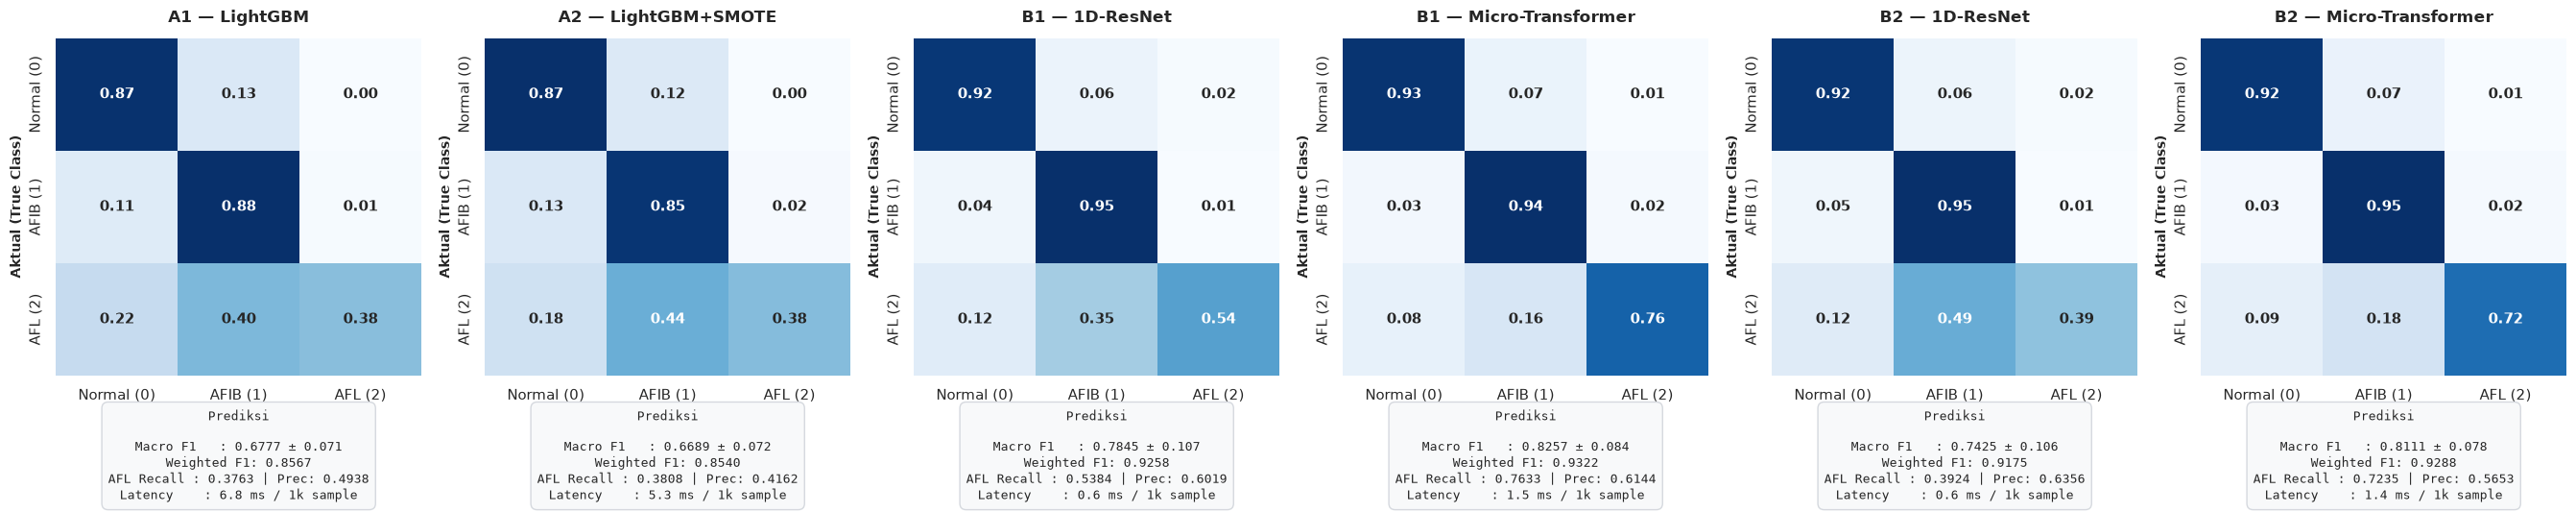

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Konfigurasi gaya visualisasi
sns.set_theme(style="white")
n_results = len(runner.results)

# Ukuran figure otomatis menyesuaikan jumlah skenario
fig, axes = plt.subplots(1, n_results, figsize=(4.5 * n_results, 5.5))
if n_results == 1:
    axes = [axes]

for ax, res in zip(axes, runner.results):
    cm = res['cm']
    scenario = res['scenario']
    model_name = res['model']
    
    # Extract metrik ringkasan dari runner.results
    macro_f1     = res.get('macro_f1', 0.0)
    macro_std    = res.get('macro_f1_std', 0.0)
    weighted_f1  = res.get('weighted_f1', 0.0)
    afl_rec      = res.get('rec_2', 0.0)
    afl_prec     = res.get('prec_2', 0.0)
    latency      = res.get('latency_ms', 0.0)
    
    # Plot Confusion Matrix Heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='.2f', 
        cmap='Blues', 
        ax=ax,
        cbar=False,  # Menghilangkan bar warna agar subplot lebih bersih
        xticklabels=['Normal (0)', 'AFIB (1)', 'AFL (2)'], 
        yticklabels=['Normal (0)', 'AFIB (1)', 'AFL (2)'],
        annot_kws={"size": 11, "weight": "bold"}
    )
    
    # Judul dan Label Sumbu
    ax.set_title(f"{scenario} — {model_name}", fontsize=12, fontweight='bold', pad=12)
    ax.set_ylabel('Aktual (True Class)', fontsize=10, fontweight='bold')
    
    # Menyusun teks metrik terstruktur dalam kotak info di bawah plot
    metrics_text = (
        f"Prediksi\n\n"
        f"Macro F1   : {macro_f1:.4f} ± {macro_std:.3f}\n"
        f"Weighted F1: {weighted_f1:.4f}\n"
        f"AFL Recall : {afl_rec:.4f} | Prec: {afl_prec:.4f}\n"
        f"Latency    : {latency:.1f} ms / 1k sample"
    )
    
    ax.set_xlabel(
        metrics_text, 
        fontsize=9.5, 
        family='monospace', 
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", edgecolor="#d1d5db", alpha=0.9)
    )

plt.tight_layout()
plt.show()

In [ ]:
import json
import time
import torch
import numpy as np
from scipy.signal import resample, find_peaks
from typing import Union

def process_and_infer(raw_input: Union[str, np.ndarray], model_weights_path: str, scaler_path: str, fs_orig: int = 250):
    target_fs = 50
    window_sec = 10
    max_beats = 30
    
    # --- 1. Load & Parsing Raw Signal ---
    if isinstance(raw_input, str):
        with open(raw_input, 'r') as f:
            raw_data = json.load(f)
        signal = np.array(raw_data)
    else:
        signal = np.array(raw_input)
        
    if signal.ndim > 1:
        signal = signal.flatten()
        
    # --- 2. Resampling & Windowing ---
    if fs_orig != target_fs:
        num_samples = int(len(signal) * target_fs / fs_orig)
        signal = resample(signal, num_samples)
        
    target_samples = window_sec * target_fs
    if len(signal) > target_samples:
        windowed_signal = signal[:target_samples]
    else:
        windowed_signal = np.pad(signal, (0, target_samples - len(signal)), 'constant')
        
    # --- 3. R-Peak Detection & Beat Extraction ---
    # Menggunakan find_peaks standar sebagai algoritma ringan
    peaks, _ = find_peaks(windowed_signal, distance=target_fs * 0.4, height=np.mean(windowed_signal))
    
    # --- 4. Robust Fallback Guard ---
    if len(peaks) < 2:
        ibi = np.array([0.8])
        dibi = np.array([0.0])
        num_beats = 0
    else:
        ibi = np.diff(peaks) / float(target_fs)
        dibi = np.concatenate(([ibi[0]], np.diff(ibi)))
        num_beats = len(ibi)
        
    # --- 5. Tensor Formatting & Masking ---
    N = min(len(ibi), max_beats)
    X = np.zeros((1, max_beats, 2), dtype=np.float32)
    M = np.zeros((1, max_beats), dtype=np.float32)
    
    if N > 0:
        X[0, :N, 0] = ibi[:N]
        X[0, :N, 1] = dibi[:N]
        M[0, :N] = 1.0
        
    # --- 6. Z-Score Standardization ---
    try:
        scaler = np.load(scaler_path)
        mean_val = scaler['mean']
        std_val = scaler['std']
    except Exception as e:
        print(f"Warning: Could not load {scaler_path} ({e}). Menggunakan dummy value.")
        mean_val = np.array([0.8, 0.0])
        std_val = np.array([0.1, 0.05])
        
    X_norm = (X - mean_val) / (std_val + 1e-8)
    X_norm = X_norm * np.expand_dims(M, -1)
    
    X_tensor = torch.tensor(X_norm, dtype=torch.float32)
    M_tensor = torch.tensor(M, dtype=torch.float32)
    
    # --- 7. Inference Engine ---
    print("=== Arrhythmia Inference Pipeline ===")
    hr_bpm = 0 if num_beats == 0 else int((num_beats / window_sec) * 60)
    
    try:
        # Inisialisasi arsitektur Micro-Transformer
        # Diasumsikan class MicroTransformer telah dijalankan dari cell sebelumnya
        model = MicroTransformer(input_dim=2, d_model=32, nhead=2, dim_ff=64, num_classes=3)
    except NameError:
        print("[!] Class MicroTransformer belum didefinisikan. Tolong jalankan cell definisi model terlebih dahulu.")
        return
        
    try:
        model.load_state_dict(torch.load(model_weights_path, map_location='cpu'))
    except FileNotFoundError:
        print(f"Warning: Bobot model '{model_weights_path}' tidak ditemukan. Menggunakan inisialisasi random.")
        
    model.eval()
    
    start_time = time.perf_counter()
    with torch.no_grad():
        # Masking untuk PyTorch: True berarti diabaikan (padding)
        # Sesuai dengan implementasi model, kita passing mask asli (M_tensor) jika model menerima mask (batch, seq) dengan 1 = asli, 0 = pad.
        # Lihat class MicroTransformer: key_pad = (mask == 0)
        logits = model(X_tensor, mask=M_tensor)
        probs = torch.softmax(logits, dim=1).squeeze(0)
    end_time = time.perf_counter()
    
    latency_ms = (end_time - start_time) * 1000.0
    classes = ["Normal", "Atrial Fibrillation (AFIB)", "Atrial Flutter (AFL)"]
    pred_idx = torch.argmax(probs).item()
    pred_class = classes[pred_idx]
    
    # --- 8. Output Summary ---
    print(f"[*] File Diproses: {raw_input if isinstance(raw_input, str) else 'Numpy Array'}")
    print(f"[*] Detak Terdeteksi: {num_beats} (Est. HR: {hr_bpm} BPM)")
    print("\n--- INFERENCE RESULTS ---")
    print(f"1. Heart Rate: {hr_bpm} BPM ({num_beats} detak dalam {window_sec} detik)")
    print(f"2. Probabilities:")
    print(f"   - Normal: {probs[0].item():.4f}")
    print(f"   - AFIB  : {probs[1].item():.4f}")
    print(f"   - AFL   : {probs[2].item():.4f}")
    print(f"3. Predicted Class: {pred_class}")
    print(f"4. Inference Latency: {latency_ms:.2f} ms")
    print("-------------------------\n")

# Eksekusi pipeline
try:
    process_and_infer(
        raw_input="raw_71.json",
        model_weights_path="micro_transformer_best.pth",
        scaler_path="scaler_params.npz",
        fs_orig=250
    )
except Exception as e:
    print(f"Error pada saat eksekusi: {e}")


=== Arrhythmia Inference Pipeline ===
[*] File Diproses: raw_71.json
[*] Detak Terdeteksi: 21 (Est. HR: 126 BPM)

--- INFERENCE RESULTS ---
1. Heart Rate: 126 BPM (21 detak dalam 10 detik)
2. Probabilities:
   - Normal: 0.1647
   - AFIB  : 0.5557
   - AFL   : 0.2796
3. Predicted Class: Atrial Fibrillation (AFIB)
4. Inference Latency: 19.37 ms
-------------------------

